In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
Data = pd.read_csv("Cards.csv",delimiter = ";",header=1,usecols=range(6))

In [3]:
print(Data.iloc[3, :])

Set                                     sor
Card ID                                   4
Name       Chirrut Îmwe, One with the Force
Number                                  1.0
Rarity                                    R
Type                                 Leader
Name: 3, dtype: object


In [4]:
Sor = Data[Data['Set'] == 'sor']
Shd = Data[Data['Set'] == 'shd']
Twi = Data[Data['Set'] == 'twi']
Jtl = Data[Data['Set'] == 'jtl']

In [5]:
Sor.iloc[0]

Set                                            sor
Card ID                                          1
Name       Director Krennic, Aspiring to Authority
Number                                         1.0
Rarity                                           C
Type                                        Leader
Name: 0, dtype: object

In [66]:
class PackOpener:
    def __init__(self,card_set):
        self.commons = card_set[(card_set['Rarity'] == 'C') & (card_set['Type'] == 'Standard')]
        self.uncommons = card_set[card_set['Rarity'] == 'U']
        self.rares = card_set[(card_set['Rarity'] == 'R') & (card_set['Type'] != 'Leader')]
        self.legendaries = card_set[card_set['Rarity'] == 'L']
    
        self.commons_leader = card_set[(card_set['Rarity'] == 'C') & (card_set['Type'] == 'Leader')]
        self.rares_leader = card_set[(card_set['Rarity'] == 'R') & (card_set['Type'] == 'Leader')]
    
        self.all = card_set[card_set['Type'] == 'Standard']
        
    def pack_open(self):
        pack_cards = []

        pack_cards.extend(self.commons.sample(9, replace=True)['Card ID'].tolist())
        pack_cards.extend(self.uncommons.sample(3, replace=True)['Card ID'].tolist())
        
        if (np.random.randint(0,8) != 0):
            pack_cards.append(self.rares.sample(1, replace=True)['Card ID'].iloc[0])
        else:
            pack_cards.append(self.legendaries.sample(1, replace=True)['Card ID'].iloc[0])
        
        i = 0
        while (i == 0):
            card = self.all.sample(1, replace=True).iloc[0]
            if (card['Rarity'] != 'Token') & (card['Rarity'] != 'S'):
                pack_cards.append(card['Card ID'])
                i = 1
        
        return pack_cards
    
    def count_hits(self, pack, hits, great_hits, L_hits):
        pack = np.array(pack,int)
        self.hits = len(pack[np.isin(pack,hits)])
        self.great_hits = len(pack[np.isin(pack,great_hits)])
        self.L_hits = len(pack[np.isin(pack,L_hits)])
        
        
    def run(self,hits, great_hits, L_hits, N):
        cumulative_hits = np.array([0,0,0])
        
        for _ in range(N):
            pack = self.pack_open()
            self.count_hits(pack, hits, great_hits, L_hits)
            cumulative_hits += np.array([self.hits,self.great_hits,self.L_hits])

        return cumulative_hits


#jtl_pack = PackOpener(Jtl)
#Hits = [37,39,45,252,84,86,88,96,150,151,164,197,210,21,38,126,133,141,213,235,41,191,204,226]
#Great_Hits = [32,242,36,43,85,89,94,140,189,201,250,142,143,203]
#L_hits = [203,143,142]

sor_pack = PackOpener(Sor)
Hits = [11,22,36,38,52,75,85,89,133,137,184,58,149,179,193,203,35,41,119,134,142,182,204]
Great_Hits = [54,82,104,122,135,145,150,152,200,201,219,246,40,43,51,87,90,102,92]
L_Hits = [40, 43, 51, 87, 90]

print(sor_pack.run(Hits,Great_Hits,L_Hits,24))
    

[16 11  2]


In [67]:
Phits = []
PGhits = []
PLhits = []

box = sor_pack
for i in range(10000):
    open_box = box.run(Hits,Great_Hits,L_Hits,24)
    Phits.append(open_box[0])
    PGhits.append(open_box[1])
    PLhits.append(open_box[2])
        

In [48]:
print(np.mean(Phits),np.std(Phits))
print(np.mean(PGhits),np.std(PGhits))
print(np.mean(PLhits),np.std(PLhits))

33.0813 5.474658921795951
14.6862 3.763579354816369
1.5027 1.2061478806514565


In [26]:
print(np.mean(Phits),np.std(Phits))
print(np.mean(PGhits),np.std(PGhits))
print(np.mean(PLhits),np.std(PLhits))

15.9263 3.648899602619946
9.35 2.748872496133642
1.4965 1.2033236264613105


0.4427


<Figure size 640x480 with 0 Axes>

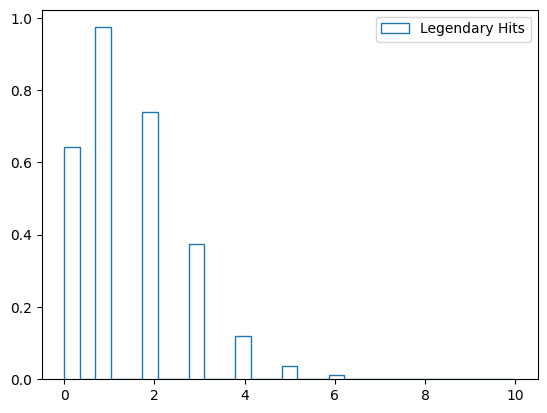

<Figure size 640x480 with 0 Axes>

In [73]:
#plt.hist(Phits,bins = np.linspace(0,60,30),histtype = 'step',density =True , label = 'hits')
#plt.hist(PGhits,bins = np.linspace(0,30,30),histtype ='step',density =True,label = 'Great Hits')
plt.hist(PLhits,bins = np.linspace(0,10,30),histtype ='step',density =True,label = 'Legendary Hits')

PLhits = np.array(PLhits)
print(len(PLhits[PLhits > 1])/10000)
plt.legend()
plt.figure()

In [75]:
print(Twi[Twi['Rarity'] == 'L'].iloc[0:60])

     Set Card ID                                      Name  Number Rarity   
551  twi      34        General Grievous, Trophy Collector     NaN      L  \
564  twi      47          Satine Kryze, Committed to Peace     1.0      L   
581  twi      64      Ki-Adi-Mundi, Composed and Confident     NaN      L   
595  twi      78              The Invasion of Christophsis     1.0      L   
613  twi      96         Aayla Secura, Master of the Blade     NaN      L   
620  twi     103                           Pyrrhic Assault     NaN      L   
633  twi     116                                     Clone     1.0      L   
635  twi     118                       Gor, Grievous's Pet     NaN      L   
652  twi     135               Darth Maul, Revenge At Last     NaN      L   
668  twi     151          Resolute, Under Anakin's Command     NaN      L   
673  twi     156                           Unlimited Power     NaN      L   
695  twi     178                        Planetary Invasion     1.0      L   

In [ ]:
#Jtl
Hits = [37,39,45,252,84,86,88,96,150,151,164,197,210,21,38,126,133,141,213,235,41,191,204,226]
Great_Hits = [32,242,36,43,85,89,94,140,189,201,250,142,143,203]
L_hits = [203,143,142]

print(len(Hits),len(Great_Hits))

In [ ]:
#Sor
Hits = [11,22,36,38,52,75,85,89,133,137,184,58,149,179,193,203,35,41,119,134,142,182,204]
Great_Hits = [54,82,104,122,135,145,150,152,200,201,219,246,40,43,51,87,90,102,92]
L_hits = [39,42,50,86,89]

print(len(Hits),len(Great_Hits))